This notebook will provide charts and visualizations comparing all of the various P300 Spelling Models created and provide a qualitative and quantitative evaluation with thoughtful discussion.

Overall Model Comparison

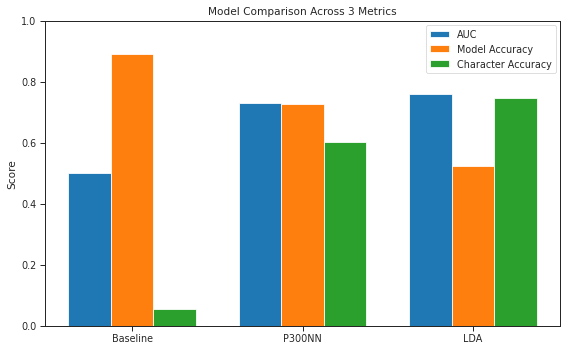

In [8]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Baseline', 'P300NN', 'LDA']

auc = [0.5, 0.7283, 0.7604]
model_accuracy = [0.8889, 0.7257, 0.5219]
char_accuracy = [0.0545, 0.6030, 0.7455]

x = np.arange(len(models))
width = 0.25 

plt.figure(figsize=(8, 5))
plt.bar(x - width, auc, width, label='AUC')
plt.bar(x, model_accuracy, width, label='Model Accuracy')
plt.bar(x + width, char_accuracy, width, label='Character Accuracy')
plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Model Comparison Across 3 Metrics')
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

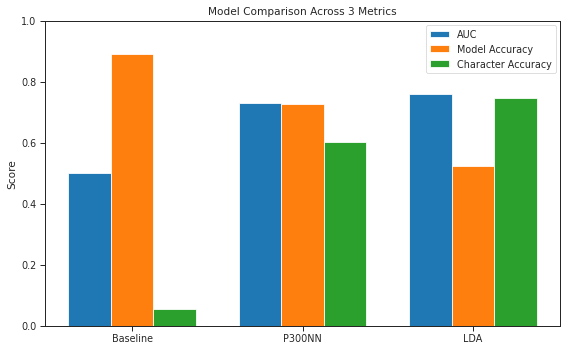

In [9]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Baseline', 'P300NN', 'LDA']

auc = [0.5, 0.7283, 0.7604]
model_accuracy = [0.8889, 0.7257, 0.5219]
char_accuracy = [0.0545, 0.6030, 0.7455]

x = np.arange(len(models))
width = 0.25 

plt.figure(figsize=(8, 5))
plt.bar(x - width, auc, width, label='AUC')
plt.bar(x, model_accuracy, width, label='Model Accuracy')
plt.bar(x + width, char_accuracy, width, label='Character Accuracy')
plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Model Comparison Across 3 Metrics')
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

AUC, Model Accuracy, Character Accuracy Per Each Participant allows for seeing how each model performed on the various metrics for each participant. 

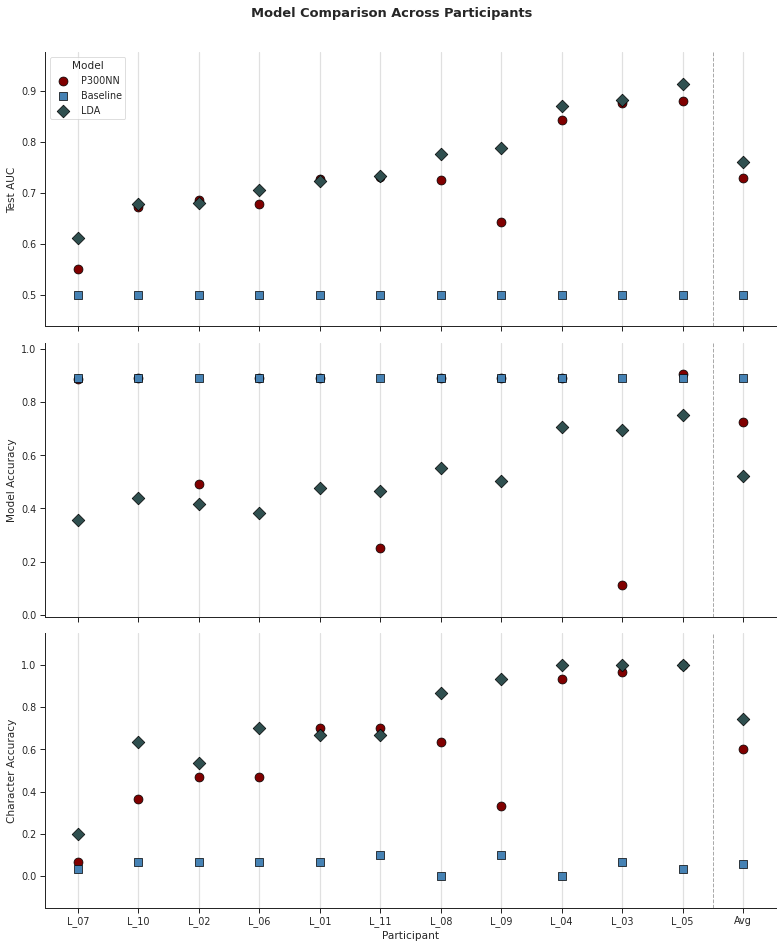

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

p300nn = {
    'participant': ['L_01','L_02','L_03','L_04','L_05','L_06','L_07','L_08','L_09','L_10','L_11'],
    'model_accuracy': [0.888889,0.491005,0.111111,0.891534,0.903968,0.888889,0.887831,0.889683,0.888889,0.888889,0.252116],
    'AUC': [0.726532,0.686843,0.877269,0.842311,0.880348,0.677540,0.550427,0.724912,0.641836,0.672984,0.730406],
    'char_accuracy': [0.700000,0.466667,0.966667,0.933333,1.000000,0.466667,0.066667,0.633333,0.333333,0.366667,0.700000],
    'Model': 'P300NN'
}

baseline = {
    'participant': ['L_01','L_02','L_03','L_04','L_05','L_06','L_07','L_08','L_09','L_10','L_11'],
    'model_accuracy': [0.888889]*11,
    'AUC': [0.5]*11,
    'char_accuracy': [0.066667,0.066667,0.066667,0.000000,0.033333,0.066667,0.033333,0.000000,0.100000,0.066667,0.100000],
    'Model': 'Baseline'
}

lda = {
    'participant': ['L_01','L_02','L_03','L_04','L_05','L_06','L_07','L_08','L_09','L_10','L_11'],
    'model_accuracy': [0.477778,0.416138,0.694444,0.706878,0.750000,0.381481,0.355291,0.552116,0.504233,0.438624,0.464021],
    'AUC': [0.724238,0.680803,0.881562,0.870270,0.914351,0.705113,0.611991,0.776574,0.788633,0.677604,0.732990],
    'char_accuracy': [0.666667,0.533333,1.000000,1.000000,1.000000,0.700000,0.200000,0.866667,0.933333,0.633333,0.666667],
    'Model': 'LDA'
}

df = pd.concat([
    pd.DataFrame(p300nn),
    pd.DataFrame(baseline),
    pd.DataFrame(lda)
], ignore_index=True)

lda_order = (
    df[df['Model'] == 'LDA']
    .set_index('participant')['AUC']
    .sort_values()
    .index.tolist()
)

metrics = ['AUC', 'model_accuracy', 'char_accuracy']

df_avg = df.groupby('Model')[metrics].mean().reset_index()
df_avg['participant'] = 'Avg'

df_final = pd.concat([df, df_avg], ignore_index=True)
final_order = lda_order + ['Avg']

plt.rcParams['font.family'] = 'serif'
sns.set_context("paper", font_scale=1.1)
sns.set_style("ticks")

fig, axes = plt.subplots(3, 1, figsize=(11, 13), sharex=True)

fig.suptitle('Model Comparison Across Participants', fontsize=13, fontweight='bold', y=1.01)

metric_labels = {
    'AUC': 'Test AUC',
    'model_accuracy': 'Model Accuracy',
    'char_accuracy': 'Character Accuracy'
}

markers = ['o', 's', 'D']
colors = ['#800000', '#4682B4', '#2F4F4F']

for ax, metric in zip(axes, metrics):

    ax.xaxis.grid(True, linestyle='-', color='#E0E0E0', linewidth=1.2)
    ax.yaxis.grid(False)

    ax.axvline(x=len(lda_order) - 0.5, color='#AAAAAA',
               linestyle='--', linewidth=1.0)

    for i, model in enumerate(df_final['Model'].unique()):
        subset = df_final[df_final['Model'] == model].copy()

        subset['participant'] = pd.Categorical(
            subset['participant'], categories=final_order, ordered=True
        )
        subset = subset.sort_values('participant')

        ax.scatter(
            subset['participant'],
            subset[metric],
            label=model,
            marker=markers[i],
            color=colors[i],
            s=80,
            edgecolor='black',
            linewidth=0.7,
            zorder=3,
        )

    ax.set_ylabel(metric_labels[metric])

    col_min = df_final[metric].min()
    col_max = df_final[metric].max()
    padding = (col_max - col_min) * 0.15
    ax.set_ylim(col_min - padding, col_max + padding)

    sns.despine(ax=ax)

axes[0].legend(title='Model', loc='upper left')

axes[-1].set_xlabel('Participant')

plt.tight_layout()
plt.show()


Qualitative and Quantitative evaluation with Discussion

This chart is ordered from the worst performing participant to the best performing participant. From these charts, one thing of interest is that we can see that the Baseline Model has the highest Model Accuracy of 89%. However in character accuracy, the baseline model acheives 7%. This clearly indicates the severe class imbalance in BCI tasks. Because the baseline model predicts the nontarget class everytime, it achieves a high accuracy even though it actually doesn't assist at all with spelling. Therefore, Model Accuracy is not the only indicator we should be looking at. When looking at the metrics that actually measure signal detection and classification success, LDA (Linear Discriminant Analysis) emerges as the best model. It achieves the highest average AUC of 0.76 and the highest Character Accuracy of 75%, successfully translating raw signal detection into practical spelling.

Qualitatively, this dataset shows that traditional machine learning (LDA) is currently much more robust than the deep learning model (P300NN) for this specific task. While the neural network shows good potential, its performance varied greatly amongst various participants as low as .55 AUC for subject L_07 and as high as .88 for L_05, indicating severe instability likely caused by a small amount of training data, high noise, or lack of practice in the BCI session. Furthermore, the participant-level data vividly captures the reality of inter-subject variability as every participant's brain signals are different. Subjects like L_07 most likely yield poor, noisy signals that cause all models to struggle, while subjects like L_03, L_04, and L_05 provide clearer signals, allowing LDA to hit a perfect 100% character accuracy. Ultimately, LDA offers the most reliable, consistent performance across varying participant signal qualities, while also being more computationally efficient. 